## Import and get the data

In [1]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
ROBOFLOW_KEY = user_secrets.get_secret("roboflow_key")

In [2]:
!pip install -Uq roboflow

from roboflow import Roboflow

# Initialize with your API key
rf = Roboflow(api_key=ROBOFLOW_KEY)

# Access the project workspace
project = rf.workspace("cv-1dnsy").project("birds-planes-drones-detector")

# Download version 2 directly
version = project.version(22)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 42.2 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Birds,-Planes,-Drones-Detector-22 in coco:: 100%|██████████| 4928/4928 [00:01<00:00, 4753.99it/s]


In [3]:
from torch import nn
from torch.utils.data import DataLoader

import requests
import torch
import torchvision
from PIL import Image
from tqdm.auto import tqdm

from torchvision.datasets import CocoDetection
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import FeaturePyramidNetwork, MultiScaleRoIAlign
from torchvision.transforms import v2 as T

In [4]:
SEED = 42
EPOCHS = 15
BATCH = 8
device = 'cuda' if torch.cuda.is_available() else "cpu"

torch.random.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

## Dataset

In [5]:
transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    #T.Resize((640, 640), antialias=True)
])

In [6]:
class CocoDataset(CocoDetection):
   def __getitem__(self, index):
      # get the image and annotations
      img, annots = super().__getitem__(index)

      # get the index
      image_id = self.ids[index]

      return img, annots, image_id

In [7]:
train_data = CocoDataset(
   root="Birds,-Planes,-Drones-Detector-22/train",
   annFile='Birds,-Planes,-Drones-Detector-22/train/_annotations.coco.json',
   transform=transform
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [8]:
def collate_fn(batch):

    images = []
    targets = []

    for image, annotations, image_id in batch:

        boxes = []
        labels = []

        for ann in annotations:

            x, y, w, h = ann["bbox"]

            # COCO → torchvision format
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            boxes.append([
                x1, y1, x2, y2
            ])

            labels.append(
                ann["category_id"]
            )

        target = {
            "boxes": torch.tensor(
                boxes,
                dtype=torch.float32
            ),

            "labels": torch.tensor(
                labels,
                dtype=torch.int64
            ),

            # ⭐ Preserve COCO image ID
            "image_id": torch.tensor(image_id),

            "iscrowd": torch.tensor(
               [ann["iscrowd"] for ann in annotations]
            ),

            "area": torch.tensor(
              [ann["area"] for ann in annotations]
            )
        }

        images.append(image)
        targets.append(target)

    return images, targets

In [9]:
train_loader = DataLoader(
   train_data,
   batch_size=BATCH,
   shuffle=False,
   pin_memory=True,
   collate_fn=collate_fn
)

In [10]:
for img, annots in train_loader:

    print([ann["image_id"] for ann in annots])

    break

[tensor(0), tensor(1), tensor(2), tensor(3), tensor(4), tensor(5), tensor(6), tensor(7)]


In [11]:
color_code = {
    0: "#FF7F0E",  # orange
    1: "#D62728",  # red
    2: "#9467BD",  # purple
    3: "#8C564B",  # brown
}

In [12]:
id_to_name = {i: j["name"] for i, j in train_data.coco.cats.items()}

In [13]:
id_to_name

{0: 'drones-planes-birds', 1: 'Airplane', 2: 'Bird', 3: 'Drone'}

In [14]:
num_classes = len(train_data.coco.cats.items())

In [15]:
import matplotlib.pyplot as plt
from matplotlib import patches


def visualize(img, target):
   fig, ax = plt.subplots(1, figsize=(10, 8))

   ax.imshow(
    img.permute(1, 2, 0).cpu().detach().numpy()
   )
   for tar in target:
     if "bbox" in tar and len(tar["bbox"]) > 0:
      x1, y1, w, h = tar["bbox"][0] if isinstance(tar["bbox"][0], list) else tar["bbox"]
      obj_id = tar["category_id"]

      rectangle = patches.Rectangle(
         (x1, y1),
         w, h,
         linewidth=2,
         edgecolor=color_code[obj_id],
         facecolor='none'
        )
      ax.add_patch(rectangle)
      ax.text(x1, y1 - 5, f"{id_to_name[obj_id]}", color=color_code[obj_id], fontsize=12, bbox=dict(facecolor="white", alpha=0.5))


   plt.axis("off")
   plt.show()

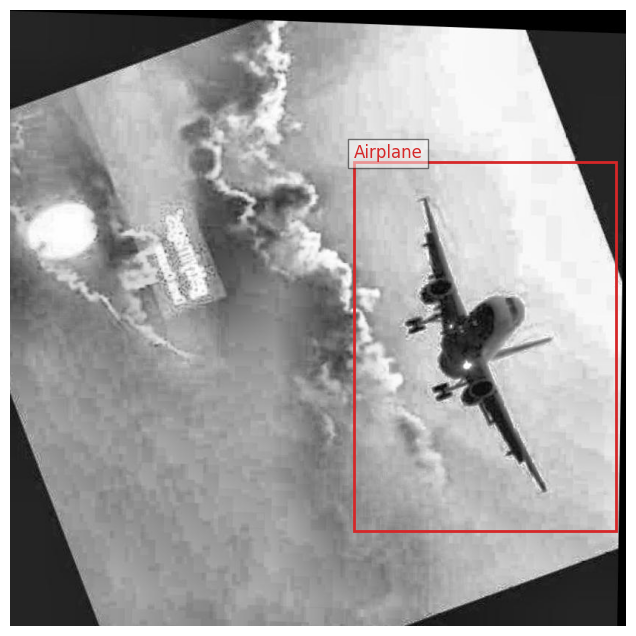

In [16]:
img, target, _ = train_data[-1]

visualize(img, target)

In [17]:
target

[{'id': 5208,
  'image_id': 4520,
  'category_id': 1,
  'bbox': [464, 205, 353.678, 498.126],
  'area': 176176.321,
  'segmentation': [],
  'iscrowd': 0}]

## Build model

In [18]:
class ResNet18FPN(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

        self.body = IntermediateLayerGetter(
            resnet,
            return_layers={
                "layer1": "0",
                "layer2": "1",
                "layer3": "2",
                "layer4": "3",
            },
        )

        self.fpn = FeaturePyramidNetwork(
            in_channels_list=[64, 128, 256, 512],
            out_channels=256,
        )

        self.out_channels = 256

    def forward(self, x):
        features = self.body(x)
        features = self.fpn(features)

        return features


In [19]:
anchor_generator = AnchorGenerator(
    sizes=((32,), (64,), (128,), (256,)),
    aspect_ratios=((0.5, 1.0, 2.0),) * 4,
)

roi_pooler = MultiScaleRoIAlign(
    featmap_names=["0", "1", "2", "3"],
    output_size=7,
    sampling_ratio=2,
)


In [20]:
backbone = ResNet18FPN()

model = FasterRCNN(
    backbone=backbone,
    num_classes=num_classes,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler,
).to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


## dummy forward pass

In [21]:
images, targets = next(iter(train_loader))

images = [
    image.to(device)
    for image in images
]

targets = [
    {
        k: v.to(device)
        for k, v in target.items()
    }
    for target in targets
]
with torch.no_grad():
    loss_dict = model(images, targets)

In [22]:
loss_dict

{'loss_classifier': tensor(1.2675, device='cuda:0'),
 'loss_box_reg': tensor(0.0127, device='cuda:0'),
 'loss_objectness': tensor(0.7025, device='cuda:0'),
 'loss_rpn_box_reg': tensor(0.2311, device='cuda:0')}

## Train

In [23]:
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr=0.0045,
    momentum=0.9,
    weight_decay=0.0005
)

In [24]:
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch: {epoch+1}")
    for i, (images, targets) in enumerate(pbar, 1):

        images = [
            image.to(device, non_blocking=True)
            for image in images
        ]

        targets = [
            {
                k: v.to(device, non_blocking=True)
                for k, v in target.items()
            }
            for target in targets
        ]

        loss_dict = model(images, targets)

        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        mean_loss = total_loss / i
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "avg loss": mean_loss})


    print(
        f"Epoch {epoch + 1}: "
        f"loss = {total_loss / len(train_loader)}"
    )

print("Training complete!")

Epoch: 1:   0%|          | 0/566 [00:00<?, ?it/s]

Epoch 1: loss = 0.2853629481007901


Epoch: 2:   0%|          | 0/566 [00:00<?, ?it/s]

Epoch 2: loss = 0.21020326128907424


Epoch: 3:   0%|          | 0/566 [00:00<?, ?it/s]

...

Epoch 13: loss = 0.1223439612415991


Epoch: 14:   0%|          | 0/566 [00:00<?, ?it/s]

Epoch 14: loss = 0.11675110461960411


Epoch: 15:   0%|          | 0/566 [00:00<?, ?it/s]

Epoch 15: loss = 0.11446888968611775
Training complete!


## Eval

In [25]:
val_data = CocoDataset(
   root="Birds,-Planes,-Drones-Detector-22/valid",
   annFile='Birds,-Planes,-Drones-Detector-22/valid/_annotations.coco.json',
   transforms=transform
)

val_loader = DataLoader(
     val_data,
     batch_size=8,
     shuffle=False,
     pin_memory=True,
     collate_fn=collate_fn
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [26]:
@torch.no_grad()
def predict(img, threshold=0.5):
  """ Predict for the image """
  model.eval()

  image = img.unsqueeze(0).to(device)
  pred = model(image)[0]
  predictions = []
    
  indices = pred["scores"] >= threshold
  labels = pred["labels"][indices].tolist()
  boxes = pred["boxes"][indices].tolist()
  scores = pred["scores"][indices].tolist()
    
  for (label, box, score) in zip(labels, boxes, scores):
     p =  {
       "category_id": label,
       "bbox": [[x1, y1, x2 - x1, y2 - y1] for x1, y1, x2, y2 in boxes],
       "score": scores
     }
     predictions.append(p)

  return predictions

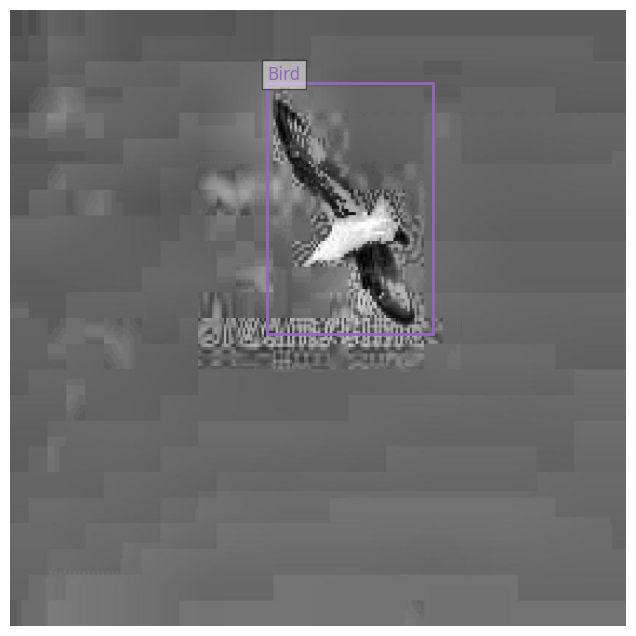

In [27]:
img, _, _ = train_data[-100]
pred = predict(img, 0.3)

visualize(img, pred)

In [28]:
pred

[{'category_id': 2,
  'bbox': [[346.9260559082031,
    98.56755828857422,
    223.23458862304688,
    338.3589859008789]],
  'score': [0.9943509101867676]}]

In [29]:
model.eval()

all_predictions = []
all_image_ids = []

with torch.no_grad():

    for images, targets in tqdm(
        val_loader,
        desc="Evaluating"
    ):
        images = [
            img.to(device)
            for img in images
        ]

        predictions = model(images)

        all_predictions.extend(predictions)

        all_image_ids.extend([
            target["image_id"].item()
            for target in targets
        ])

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

In [30]:
def to_coco_results(predictions, image_ids, threshold):

    results = []

    for prediction, image_id in zip(
        predictions,
        image_ids
    ):
        keep = prediction["scores"] >= threshold
        boxes = prediction["boxes"][keep].cpu()
        labels = prediction["labels"][keep].cpu()
        scores = prediction["scores"][keep].cpu()

        for box, label, score in zip(
            boxes,
            labels,
            scores
        ):
            x1, y1, x2, y2 = box.tolist()

            results.append({
                "image_id": int(image_id),
                "category_id": int(label),
                "bbox": [
                    x1,
                    y1,
                    x2 - x1,
                    y2 - y1
                ],
                "score": float(score)
            })

    return results

In [31]:
coco_results = to_coco_results(
    all_predictions,
    all_image_ids,
    threshold=0.25
)

print("Predictions:", len(coco_results))
print(coco_results[:2])

Predictions: 275
[{'image_id': 0, 'category_id': 1, 'bbox': [279.67108154296875, 315.07421875, 293.02069091796875, 201.7049560546875], 'score': 0.9925963878631592}, {'image_id': 1, 'category_id': 2, 'bbox': [16.69065284729004, 145.0984344482422, 607.462911605835, 605.3083648681641], 'score': 0.4132206439971924}]


In [32]:
from pycocotools.cocoeval import COCOeval

coco_gt = val_data.coco
coco_dt = coco_gt.loadRes(
  coco_results
)

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!


In [33]:
coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.21s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.378
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.850
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.242
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.166
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.263
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.424
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.441
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.462
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.462
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.188
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100

## Try with images from the internet

![Plane Image](https://cdn.pixabay.com/photo/2023/07/11/03/27/aircraft-8119477_640.jpg)

![Bird Image](https://cdn.pixabay.com/photo/2017/03/13/10/25/hummingbird-2139278_1280.jpg)

![Drone Image](https://media.istockphoto.com/id/871275082/photo/flying-drone-at-night.jpg?s=612x612&w=0&k=20&c=XJkbG7AsYNpW1uYvxMqoJH6IfBR-CirGJjDQUYuu7Gc=)

In [34]:
urls = [
  "https://cdn.pixabay.com/photo/2023/07/11/03/27/aircraft-8119477_640.jpg",
  "https://cdn.pixabay.com/photo/2017/03/13/10/25/hummingbird-2139278_1280.jpg",
  "https://media.istockphoto.com/id/871275082/photo/flying-drone-at-night.jpg?s=612x612&w=0&k=20&c=XJkbG7AsYNpW1uYvxMqoJH6IfBR-CirGJjDQUYuu7Gc="
]

headers = {
  "user-agent": "Learner"
}

for i, url in enumerate(urls, 1):
   res = requests.get(url, headers=headers)

   with open(f"{i}.jpg", "wb") as f:
     f.write(res.content)

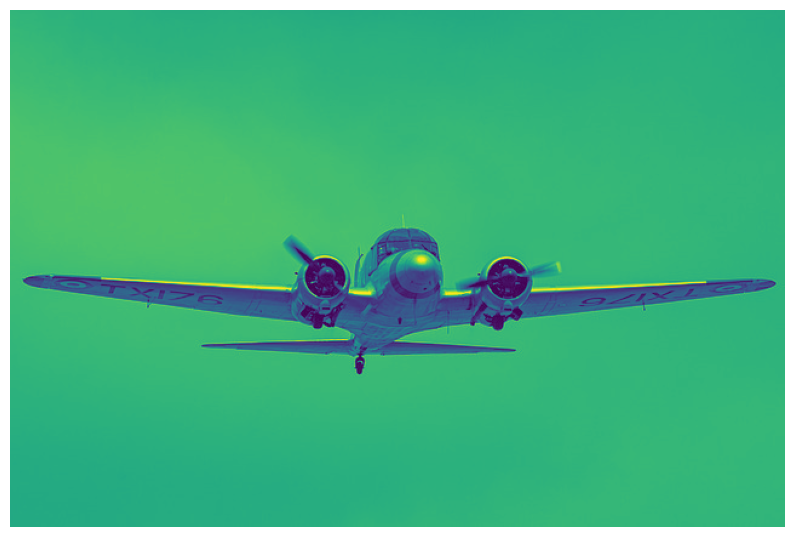

In [35]:
airplane = Image.open("1.jpg").convert("L")

result = predict(transform(airplane), 0.2)
visualize(transform(airplane), [result])

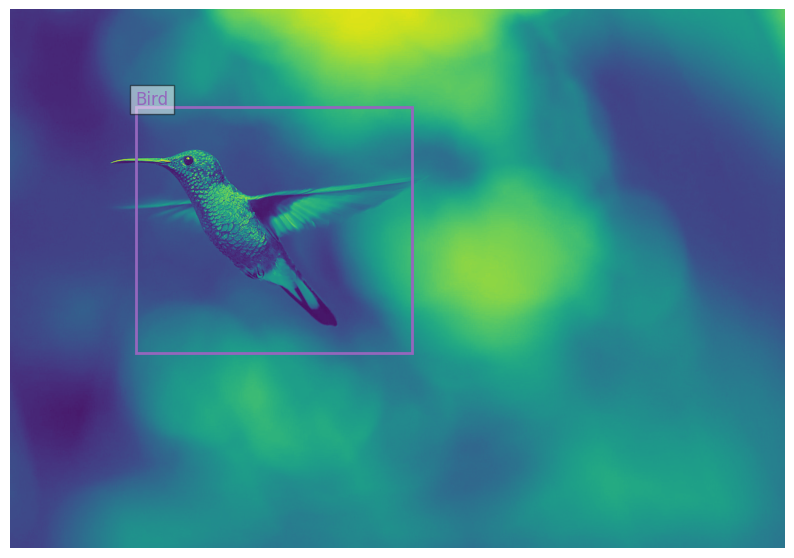

In [36]:
bird = Image.open("2.jpg").convert("L")

result = predict(transform(bird), 0.25)
visualize(transform(bird), result)

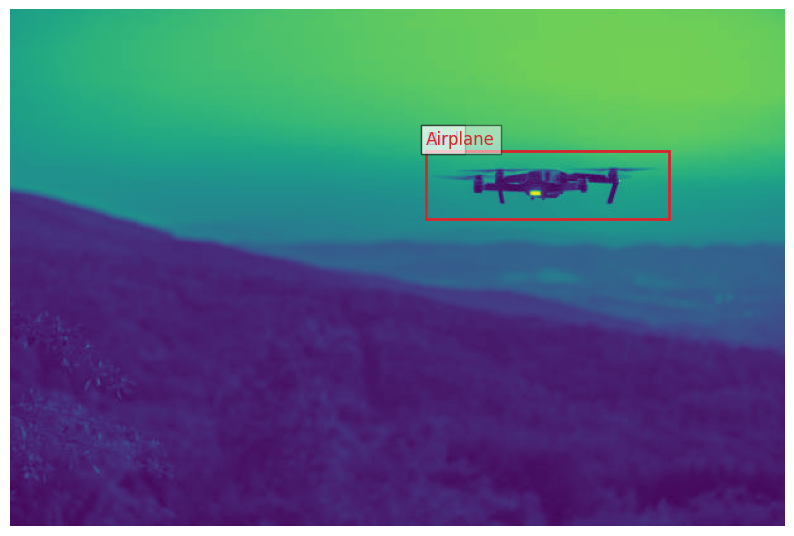

In [37]:
drone = Image.open("3.jpg").convert("L")

result = predict(transform(drone), threshold=0.3)
visualize(transform(drone), result)

In [38]:
model.eval()
torch.save(model, "aerial_object_detection_resnet18.pt")
!rm -rf "/kaggle/working/Birds,-Planes,-Drones-Detector-22"